In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
BASE_DIR = "/content/drive/MyDrive/WORK/WAGON/DermAI/dataset"

os.chdir(BASE_DIR)      # on se place dans ce dossier
print(os.getcwd())
!ls

/content/drive/MyDrive/WORK/WAGON/DermAI/dataset
HAM10000_images_part_1	HAM10000_metadata.gsheet  hmnist_8_8_L.csv
HAM10000_images_part_2	hmnist_28_28_L.csv	  hmnist_8_8_RGB.csv
HAM10000_metadata.csv	hmnist_28_28_RGB.csv	  notebook_derma_ai_data.ipynb


In [3]:
import os
print(os.getcwd())
!ls

/content/drive/MyDrive/WORK/WAGON/DermAI/dataset
HAM10000_images_part_1	HAM10000_metadata.gsheet  hmnist_8_8_L.csv
HAM10000_images_part_2	hmnist_28_28_L.csv	  hmnist_8_8_RGB.csv
HAM10000_metadata.csv	hmnist_28_28_RGB.csv	  notebook_derma_ai_data.ipynb


In [4]:
# Étape 1 : imports et config de base

import os
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow version:", tf.__version__)

# Chemins vers les données (adapter si besoin)
METADATA_CSV = "HAM10000_metadata.csv"
IMAGES_DIR_1 = "HAM10000_images_part_1"
IMAGES_DIR_2 = "HAM10000_images_part_2"

# Paramètres généraux
IMG_SIZE = 224          # taille d'entrée pour ResNet/DenseNet (carrée)
BATCH_SIZE = 32
SEED = 42
EPOCHS_SIMPLE = 15
EPOCHS_TRANSFER = 15

AUTOTUNE = tf.data.AUTOTUNE

# Fixer les seeds pour un peu de reproductibilité
tf.random.set_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)


TensorFlow version: 2.19.0


In [5]:
# Étape 2 : chargement du CSV et sélection des colonnes utiles

meta = pd.read_csv(METADATA_CSV)
print("Taille du CSV :", meta.shape)
display(meta.head())

# Colonnes nécessaires pour le MVP
cols_mvp = ["image_id", "lesion_id", "dx"]
df = meta[cols_mvp].copy()

# Suppression d'éventuels doublons sur image_id
df = df.drop_duplicates(subset="image_id").reset_index(drop=True)

print("Taille après sélection des colonnes :", df.shape)
display(df.head())

# Vérification des valeurs manquantes
print("\nValeurs manquantes :")
print(df.isna().sum())


Taille du CSV : (10015, 7)


,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


Taille après sélection des colonnes : (10015, 3)


,image_id,lesion_id,dx
0,ISIC_0027419,HAM_0000118,bkl
1,ISIC_0025030,HAM_0000118,bkl
2,ISIC_0026769,HAM_0002730,bkl
3,ISIC_0025661,HAM_0002730,bkl
4,ISIC_0031633,HAM_0001466,bkl



Valeurs manquantes :
image_id     0
lesion_id    0
dx           0
dtype: int64


In [6]:
# Étape 3 : ajouter la colonne image_path en cherchant dans part_1 puis part_2

def find_image_path(image_id):
    """Retourne le chemin du fichier image en cherchant dans part_1 puis part_2."""
    filename = image_id + ".jpg"
    p1 = os.path.join(IMAGES_DIR_1, filename)
    if os.path.exists(p1):
        return p1
    p2 = os.path.join(IMAGES_DIR_2, filename)
    if os.path.exists(p2):
        return p2
    return None

df["image_path"] = df["image_id"].apply(find_image_path)

missing = df["image_path"].isna().sum()
print("Images introuvables :", missing)

# On enlève les lignes où l'image n'a pas été trouvée
df = df[~df["image_path"].isna()].reset_index(drop=True)
print("Taille finale du DataFrame après filtrage :", df.shape)
display(df.head())


Images introuvables : 0
Taille finale du DataFrame après filtrage : (10015, 4)


,image_id,lesion_id,dx,image_path
0,ISIC_0027419,HAM_0000118,bkl,HAM10000_images_part_1/ISIC_0027419.jpg
1,ISIC_0025030,HAM_0000118,bkl,HAM10000_images_part_1/ISIC_0025030.jpg
2,ISIC_0026769,HAM_0002730,bkl,HAM10000_images_part_1/ISIC_0026769.jpg
3,ISIC_0025661,HAM_0002730,bkl,HAM10000_images_part_1/ISIC_0025661.jpg
4,ISIC_0031633,HAM_0001466,bkl,HAM10000_images_part_2/ISIC_0031633.jpg


In [7]:
# Étape 4 : encodage des labels

class_names = sorted(df["dx"].unique())
class_to_index = {name: idx for idx, name in enumerate(class_names)}
index_to_class = {idx: name for name, idx in class_to_index.items()}

df["label"] = df["dx"].map(class_to_index)

num_classes = len(class_names)
print("Classes :", class_names)
print("Nombre de classes :", num_classes)

display(df.head())


Classes : ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Nombre de classes : 7


,image_id,lesion_id,dx,image_path,label
0,ISIC_0027419,HAM_0000118,bkl,HAM10000_images_part_1/ISIC_0027419.jpg,2
1,ISIC_0025030,HAM_0000118,bkl,HAM10000_images_part_1/ISIC_0025030.jpg,2
2,ISIC_0026769,HAM_0002730,bkl,HAM10000_images_part_1/ISIC_0026769.jpg,2
3,ISIC_0025661,HAM_0002730,bkl,HAM10000_images_part_1/ISIC_0025661.jpg,2
4,ISIC_0031633,HAM_0001466,bkl,HAM10000_images_part_2/ISIC_0031633.jpg,2


In [8]:
# Étape 5 : split au niveau des lesion_id (pour éviter la fuite de données)

# DataFrame au niveau des lésions
lesion_df = df.groupby("lesion_id")["dx"].first().reset_index()

train_lesions, temp_lesions = train_test_split(
    lesion_df,
    test_size=0.3,
    random_state=SEED,
    stratify=lesion_df["dx"],
)

val_lesions, test_lesions = train_test_split(
    temp_lesions,
    test_size=0.5,
    random_state=SEED,
    stratify=temp_lesions["dx"],
)

train_ids = set(train_lesions["lesion_id"])
val_ids = set(val_lesions["lesion_id"])
test_ids = set(test_lesions["lesion_id"])

def split_df(df, train_ids, val_ids, test_ids):
    train_df = df[df["lesion_id"].isin(train_ids)].copy()
    val_df = df[df["lesion_id"].isin(val_ids)].copy()
    test_df = df[df["lesion_id"].isin(test_ids)].copy()
    return train_df, val_df, test_df

train_df, val_df, test_df = split_df(df, train_ids, val_ids, test_ids)

print("Taille train :", train_df.shape)
print("Taille val   :", val_df.shape)
print("Taille test  :", test_df.shape)

print("\nRépartition des classes (train) :")
display(train_df["dx"].value_counts())


Taille train : (6981, 5)
Taille val   : (1532, 5)
Taille test  : (1502, 5)

Répartition des classes (train) :


,count
dx,
nv,4683
mel,773
bkl,772
bcc,361
akiec,222
vasc,99
df,71


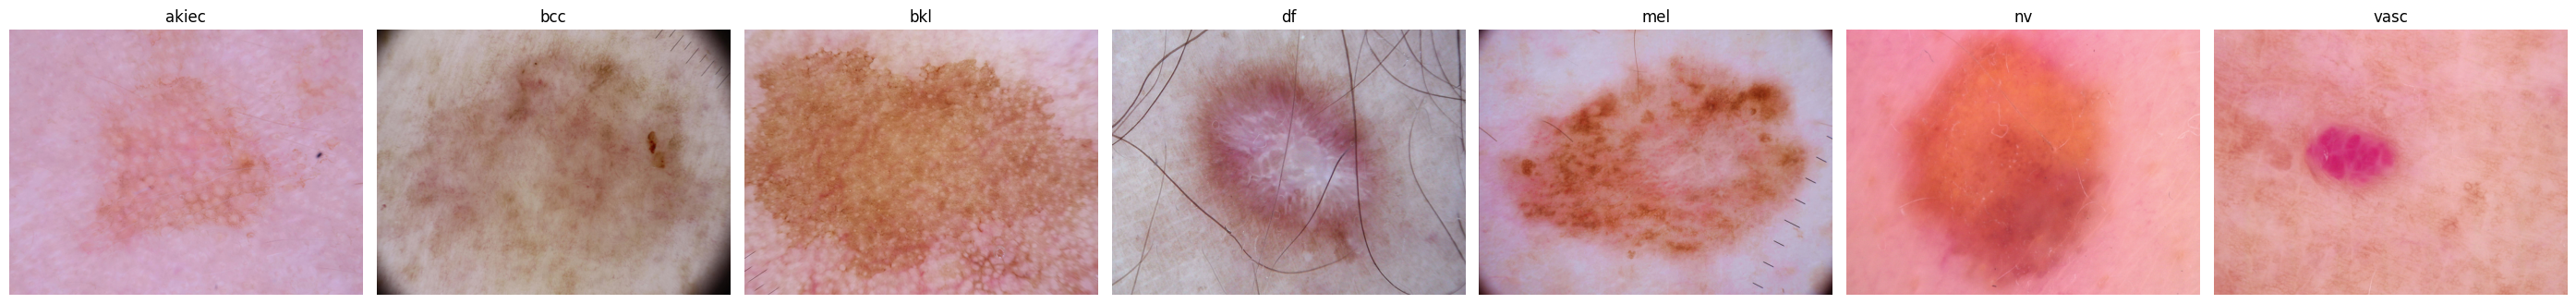

In [9]:
# Étape 6 : afficher une image par type de lésion

def show_one_image_per_class(df, class_names, seed=SEED):
    plt.figure(figsize=(4 * len(class_names), 4))
    for i, cls in enumerate(class_names):
        sample = df[df["dx"] == cls].sample(1, random_state=seed)
        img_path = sample["image_path"].values[0]
        img = plt.imread(img_path)
        ax = plt.subplot(1, len(class_names), i + 1)
        plt.imshow(img)
        plt.title(cls)
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_one_image_per_class(df, class_names)


In [10]:
# Étape 7 : création des datasets TensorFlow (tf.data)

def df_to_dataset(df_subset, shuffle=True):
    paths = df_subset["image_path"].values
    labels = df_subset["label"].values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))

    def load_image(path, label):
        image = tf.io.read_file(path)
        image = tf.image.decode_jpeg(image, channels=3)
        image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
        image = tf.cast(image, tf.float32) / 255.0
        return image, label

    ds = ds.map(load_image, num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(df_subset), seed=SEED)

    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds

train_ds = df_to_dataset(train_df, shuffle=True)
val_ds = df_to_dataset(val_df, shuffle=False)
test_ds = df_to_dataset(test_df, shuffle=False)

train_ds


<_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>

In [11]:
# Étape 8 : data augmentation + rééquilibrage

# Couche de data augmentation
data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)

# Sur-échantillonnage pour équilibrer les classes
def make_balanced_df(train_df, seed=SEED):
    dfs = []
    max_count = train_df["dx"].value_counts().max()
    for cls, group in train_df.groupby("dx"):
        dfs.append(group.sample(max_count, replace=True, random_state=seed))
    balanced = pd.concat(dfs).sample(frac=1.0, random_state=seed).reset_index(drop=True)
    return balanced

balanced_train_df = make_balanced_df(train_df)
print("Répartition des classes dans le train rééquilibré :")
display(balanced_train_df["dx"].value_counts())

balanced_train_ds = df_to_dataset(balanced_train_df, shuffle=True)


Répartition des classes dans le train rééquilibré :


,count
dx,
vasc,4683
bkl,4683
akiec,4683
df,4683
nv,4683
bcc,4683
mel,4683


In [12]:
# Étape 9 : fonction utilitaire pour tracer les courbes

def plot_history(history, title_suffix=""):
    hist = history.history
    epochs = range(1, len(hist["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, hist["loss"], label="Train loss")
    plt.plot(epochs, hist["val_loss"], label="Val loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Loss " + title_suffix)
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, hist["accuracy"], label="Train acc")
    plt.plot(epochs, hist["val_accuracy"], label="Val acc")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Accuracy " + title_suffix)
    plt.legend()

    plt.show()


Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,663 (432.28 KB)

 Trainable params: 110,663 (432.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 363s 273ms/step - accuracy: 0.6037 - loss: 1.4553 - val_accuracy: 0.6645 - val_loss: 1.1213
Epoch 2/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 51ms/step - accuracy: 0.6730 - loss: 1.1300 - val_accuracy: 0.6645 - val_loss: 1.0822
Epoch 3/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6736 - loss: 1.0612 - val_accuracy: 0.6645 - val_loss: 1.0719
Epoch 4/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6721 - loss: 1.0693 - val_accuracy: 0.6645 - val_loss: 1.0673
Epoch 5/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6699 - loss: 1.0481 - val_accuracy: 0.6645 - val_loss: 1.0539
Epoch 6/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 50ms/step - accuracy: 0.6668 - loss: 1.0457 - val_accuracy: 0.6645 - val_loss: 1.0466
Epoch 7/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6776 - loss: 1.0008 - val_accuracy: 0.6645 - val_loss: 1.0253
Epoch 8/15
219/219 ━━━━━━━━━━━━━━━━━━━━ 22s 49ms/step - accuracy: 0.6758 - loss: 0.9983 

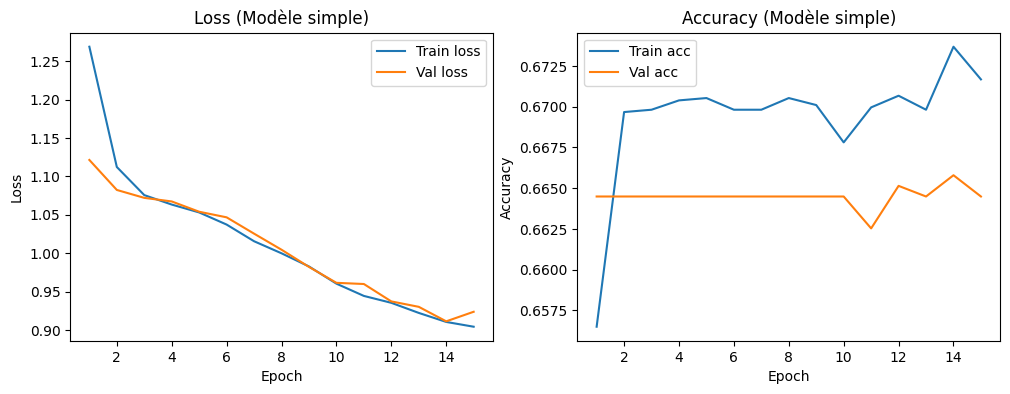

In [13]:
# Étape 10 : modèle 1 – CNN simple (baseline)

def build_simple_cnn(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=num_classes, use_augmentation=False):
    inputs = keras.Input(shape=input_shape)
    x = inputs

    if use_augmentation:
        x = data_augmentation(x)

    x = layers.Conv2D(32, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(64, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.Conv2D(128, 3, activation="relu")(x)
    x = layers.MaxPooling2D()(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="simple_cnn")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

simple_model = build_simple_cnn()
simple_model.summary()

history_simple = simple_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SIMPLE
)

plot_history(history_simple, "(Modèle simple)")

Model: "simple_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 110,663 (432.28 KB)

 Trainable params: 110,663 (432.28 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 95s 37ms/step - accuracy: 0.2087 - loss: 1.8960 - val_accuracy: 0.4256 - val_loss: 1.5627
Epoch 2/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 90s 37ms/step - accuracy: 0.3419 - loss: 1.6641 - val_accuracy: 0.4732 - val_loss: 1.3959
Epoch 3/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 91s 37ms/step - accuracy: 0.4038 - loss: 1.5391 - val_accuracy: 0.4765 - val_loss: 1.3385
Epoch 4/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 90s 37ms/step - accuracy: 0.4532 - loss: 1.4317 - val_accuracy: 0.5046 - val_loss: 1.2111
Epoch 5/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 90s 37ms/step - accuracy: 0.4935 - loss: 1.3477 - val_accuracy: 0.4634 - val_loss: 1.3133
Epoch 6/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 90s 37ms/step - accuracy: 0.5063 - loss: 1.3031 - val_accuracy: 0.4954 - val_loss: 1.2216
Epoch 7/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 90s 37ms/step - accuracy: 0.5051 - loss: 1.2786 - val_accuracy: 0.4687 - val_loss: 1.2714
Epoch 8/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 90s 37ms/step - accuracy: 0.5171 -

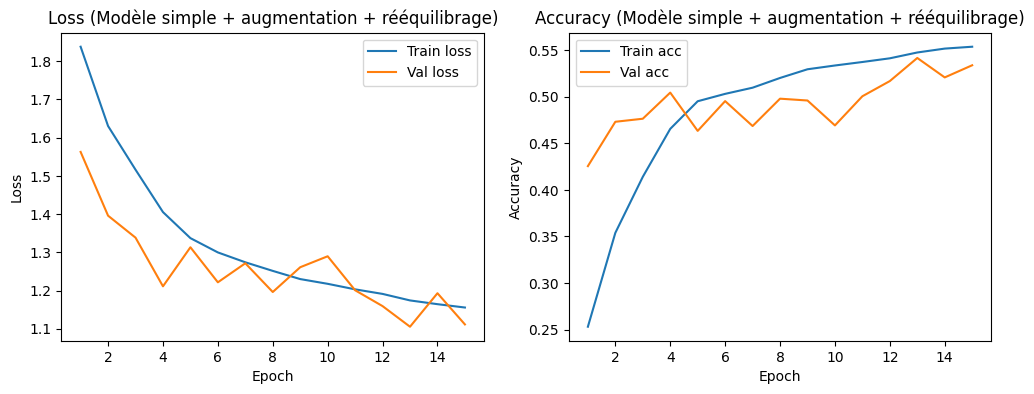

In [14]:
# Étape 11 : modèle 2 – CNN simple + data augmentation + dataset équilibré

simple_model_aug = build_simple_cnn(use_augmentation=True)
simple_model_aug.summary()

history_simple_aug = simple_model_aug.fit(
    balanced_train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_SIMPLE
)

plot_history(history_simple_aug, "(Modèle simple + augmentation + rééquilibrage)")


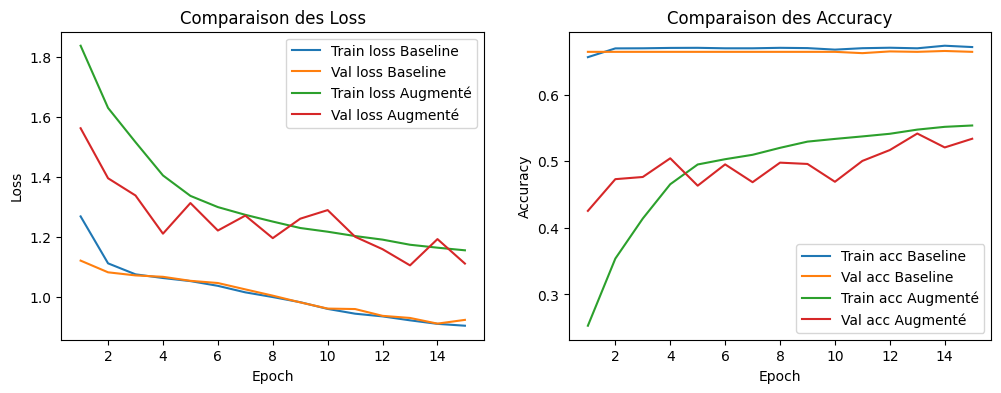

In [15]:
# Comparaison des courbes baseline vs augmentation

def compare_histories(history1, history2, labels=("Baseline", "Augmenté")):
    h1 = history1.history
    h2 = history2.history
    epochs = range(1, len(h1["loss"]) + 1)

    plt.figure(figsize=(12, 4))

    # Loss
    plt.subplot(1, 2, 1)
    plt.plot(epochs, h1["loss"], label=f"Train loss {labels[0]}")
    plt.plot(epochs, h1["val_loss"], label=f"Val loss {labels[0]}")
    plt.plot(epochs, h2["loss"], label=f"Train loss {labels[1]}")
    plt.plot(epochs, h2["val_loss"], label=f"Val loss {labels[1]}")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Comparaison des Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1, 2, 2)
    plt.plot(epochs, h1["accuracy"], label=f"Train acc {labels[0]}")
    plt.plot(epochs, h1["val_accuracy"], label=f"Val acc {labels[0]}")
    plt.plot(epochs, h2["accuracy"], label=f"Train acc {labels[1]}")
    plt.plot(epochs, h2["val_accuracy"], label=f"Val acc {labels[1]}")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("Comparaison des Accuracy")
    plt.legend()

    plt.show()

compare_histories(history_simple, history_simple_aug)


29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "densenet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ add (Add)                       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide_1 (TrueDivide)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,703 (27.85 MB)

 Trainable params: 264,199 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 148s 81ms/step - accuracy: 0.1472 - loss: 1.9958 - val_accuracy: 0.4778 - val_loss: 1.9205
Epoch 2/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.1767 - loss: 1.9332 - val_accuracy: 0.0516 - val_loss: 1.9326
Epoch 3/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.1875 - loss: 1.9227 - val_accuracy: 0.3603 - val_loss: 1.8873
Epoch 4/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.2011 - loss: 1.9112 - val_accuracy: 0.0320 - val_loss: 1.9541
Epoch 5/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.2032 - loss: 1.9007 - val_accuracy: 0.1044 - val_loss: 1.9095
Epoch 6/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.2122 - loss: 1.8907 - val_accuracy: 0.0927 - val_loss: 1.9123
Epoch 7/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 76ms/step - accuracy: 0.2261 - loss: 1.8811 - val_accuracy: 0.1247 - val_loss: 1.9313
Epoch 8/15
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 

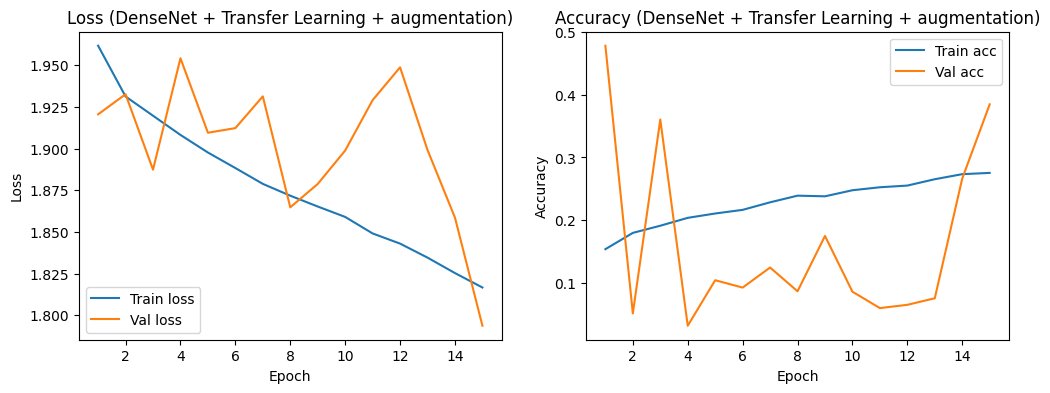

47/47 ━━━━━━━━━━━━━━━━━━━━ 48s 1s/step - accuracy: 0.2781 - loss: 1.8183
Test accuracy (DenseNet) : 0.41544607281684875


In [16]:
# Étape 12 : modèle 3 – DenseNet121 (Transfer Learning) + augmentation

from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

def build_densenet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=num_classes):
    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    base_model.trainable = False  # on gèle le backbone pour commencer

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)
    x = densenet_preprocess(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="densenet_transfer")
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-4),
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

densenet_model = build_densenet_model()
densenet_model.summary()

history_densenet = densenet_model.fit(
    balanced_train_ds,
    validation_data=val_ds,
    epochs=EPOCHS_TRANSFER
)

plot_history(history_densenet, "(DenseNet + Transfer Learning + augmentation)")

# Évaluation sur le test set
test_loss, test_acc = densenet_model.evaluate(test_ds)
print("Test accuracy (DenseNet) :", test_acc)


Model: "densenet_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_6 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ densenet121 (Functional)        │ (None, 7, 7, 1024)     │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1024)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 7)              │         1,799 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,703 (27.85 MB)

 Trainable params: 264,199 (1.01 MB)

 Non-trainable params: 7,037,504 (26.85 MB)

Epoch 1/25
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 149s 81ms/step - accuracy: 0.3054 - loss: 1.7910 - val_accuracy: 0.5326 - val_loss: 1.2338
Epoch 2/25
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.5258 - loss: 1.2815 - val_accuracy: 0.5437 - val_loss: 1.1789
Epoch 3/25
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.5894 - loss: 1.1283 - val_accuracy: 0.5764 - val_loss: 1.1014
Epoch 4/25
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.6100 - loss: 1.0540 - val_accuracy: 0.5581 - val_loss: 1.1245
Epoch 5/25
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.6445 - loss: 0.9732 - val_accuracy: 0.5816 - val_loss: 1.0856
Epoch 6/25
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.6675 - loss: 0.9182 - val_accuracy: 0.5875 - val_loss: 1.0868
Epoch 7/25
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 0.6786 - loss: 0.8850 - val_accuracy: 0.5992 - val_loss: 1.0249
Epoch 8/25
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 131s 77ms/step - accuracy: 

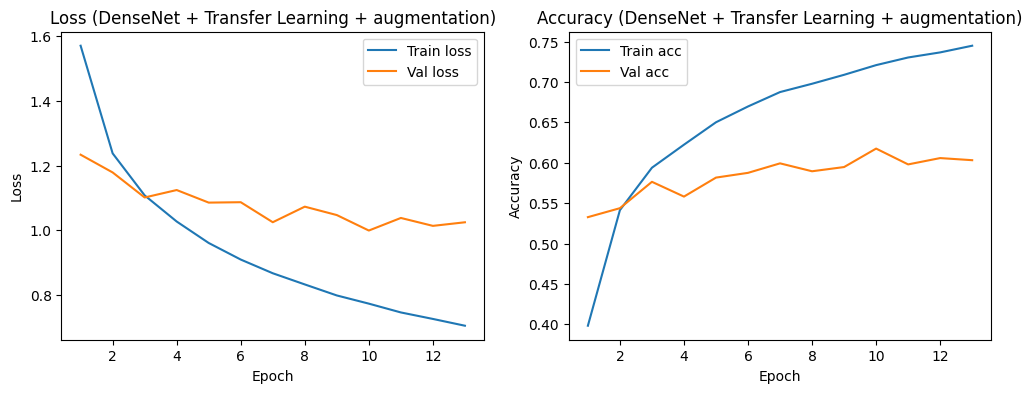

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.6516 - loss: 0.9303
Test accuracy (DenseNet) : 0.6218375563621521


In [17]:
# Étape 12 Bis (corrigée) : DenseNet121 + data augmentation (sans double préprocessing)

from tensorflow.keras.applications import DenseNet121

def build_densenet_model(input_shape=(IMG_SIZE, IMG_SIZE, 3), num_classes=num_classes):
    base_model = DenseNet121(
        include_top=False,
        weights="imagenet",
        input_shape=input_shape
    )
    # On gèle le backbone pour commencer
    base_model.trainable = False

    inputs = keras.Input(shape=input_shape)
    x = data_augmentation(inputs)        # data augmentation sur images en [0,1]
    # PAS de densenet_preprocess ici : les images sont déjà normalisées 0–1
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation="relu")(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name="densenet_transfer")

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=5e-5),  # un peu plus petit
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

densenet_model = build_densenet_model()
densenet_model.summary()

# Early stopping pour ne pas sur-entraîner
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

history_densenet = densenet_model.fit(
    balanced_train_ds,          # dataset rééquilibré + augmentation dans le modèle
    validation_data=val_ds,
    epochs=25,                  # un peu plus d'epochs, mais stoppés tôt si besoin
    callbacks=[early_stop]
)

plot_history(history_densenet, "(DenseNet + Transfer Learning + augmentation)")

# Évaluation finale sur le test set
test_loss, test_acc = densenet_model.evaluate(test_ds)
print("Test accuracy (DenseNet) :", test_acc)


input_layer_6
Nombre total de couches DenseNet : 427
Couches gelées jusqu'à l'indice : 298
Epoch 1/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 205s 116ms/step - accuracy: 0.5851 - loss: 1.1757 - val_accuracy: 0.6299 - val_loss: 1.0117
Epoch 2/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.7573 - loss: 0.6355 - val_accuracy: 0.6717 - val_loss: 0.9088
Epoch 3/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.8152 - loss: 0.4920 - val_accuracy: 0.6841 - val_loss: 0.9107
Epoch 4/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.8606 - loss: 0.3878 - val_accuracy: 0.6991 - val_loss: 0.8778
Epoch 5/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.8863 - loss: 0.3142 - val_accuracy: 0.7010 - val_loss: 0.9012
Epoch 6/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.9071 - loss: 0.2598 - val_accuracy: 0.7004 - val_loss: 0.9424
Epoch 7/10
1025/1025 ━━━━━━━━━━━━━━━━━━━━ 166s 110ms/step - accuracy: 0.9231 - loss: 0.2175 - val_accurac

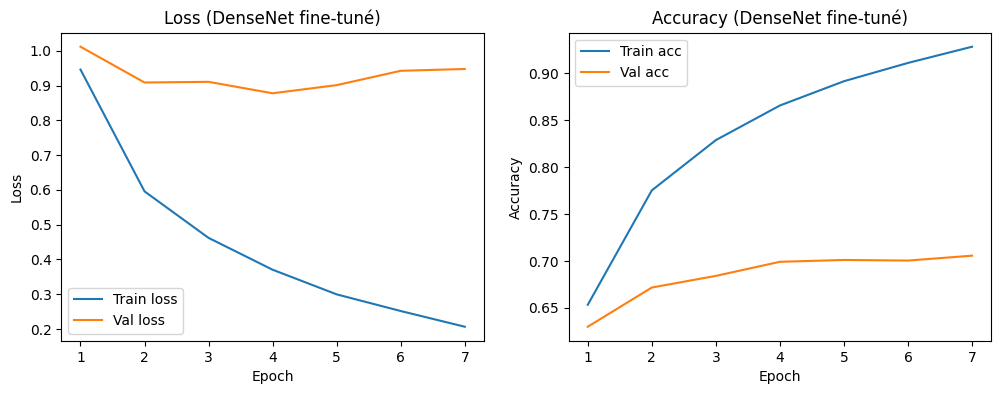

47/47 ━━━━━━━━━━━━━━━━━━━━ 3s 69ms/step - accuracy: 0.7336 - loss: 0.7833
Test accuracy après fine-tuning : 0.7190412878990173


In [18]:
# Fine-tuning : dé-geler une partie des couches DenseNet

# 1) Récupérer le backbone DenseNet dans le modèle complet
# (son nom par défaut est généralement "densenet121")
for layer in densenet_model.layers:
    print(layer.name)
    break
# Si tu veux vérifier, tu peux faire : densenet_model.summary() une fois

base_model = densenet_model.get_layer("densenet121")  # nom du backbone
base_model.trainable = True

# 2) On ne dé-gèle que ~30% des couches les plus profondes
fine_tune_at = int(len(base_model.layers) * 0.7)
for i, layer in enumerate(base_model.layers):
    if i < fine_tune_at:
        layer.trainable = False

print("Nombre total de couches DenseNet :", len(base_model.layers))
print("Couches gelées jusqu'à l'indice :", fine_tune_at)

# 3) Re-compiler avec un learning rate plus petit
densenet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

# 4) Early stopping pour ne pas sur-entraîner
early_stop_ft = keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)

# 5) Fine-tuning
history_ft = densenet_model.fit(
    balanced_train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=[early_stop_ft]
)

plot_history(history_ft, "(DenseNet fine-tuné)")

# 6) Évaluation finale sur le test set
test_loss, test_acc = densenet_model.evaluate(test_ds)
print("Test accuracy après fine-tuning :", test_acc)


In [19]:
MODEL_PATH = "skin_lesion_densenet_finetuned.h5"
densenet_model.save(MODEL_PATH)
print("Modèle sauvegardé sous :", MODEL_PATH)


Modèle sauvegardé sous : skin_lesion_densenet_finetuned.h5


In [23]:
# Étape 14 : prédiction sur une image choisie

def load_and_preprocess_image(path):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.expand_dims(image, axis=0)
    return image

def predict_image(model, img_path, class_names):
    img = load_and_preprocess_image(img_path)
    preds = model.predict(img)
    pred_index = np.argmax(preds[0])
    pred_class = class_names[pred_index]
    print("Lésion prédite :", pred_class)

# Exemple d'utilisation (adapter le chemin !) :
test_image_path = "HAM10000_images_part_1/ISIC_0028393.jpg"  # à adapter
predict_image(densenet_model, test_image_path, class_names)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Lésion prédite : akiec


In [24]:
# Sauvegarde du modèle final au format .keras

FINAL_MODEL_PATH = "skin_lesion_densenet_finetuned.keras"
densenet_model.save(FINAL_MODEL_PATH)
print("Modèle sauvegardé sous :", FINAL_MODEL_PATH)


Modèle sauvegardé sous : skin_lesion_densenet_finetuned.keras
